# MNIST Supplemental

### MATH 637 — Mathematical Techniques in Data Science · Final Project · Spring 2026

**Team Members**

| Name | Email |
|------|-------|
| Skylar Callis | sjcallis@udel.edu |
| Charles Hart | chharles@udel.edu |
| Sean Hazen | hazen@udel.edu |
| Joeal Bijoy Thomas | joeal@udel.edu |

**Instructor:** Dominique Guillot, University of Delaware

**Note for Dominique:** Hi Dominique, this is a notebook that goes through training a MAF normalizing flow on the full-size MNIST dataset using Zuko. We (almost entirely Joeal) put this together after our presentation, at your request. We (Skylar) haven't checked the text components, as this was split off from an older version of our tutorial. 

## A Masked Autoregressive Flow on MNIST with Zuko

The from-scratch MAF above is great pedagogy but in practice you'd never maintain hundreds of lines of masking code by hand. The community-standard library is **[Zuko](https://zuko.readthedocs.io/stable/)** [Rozet et al., 2024], a lightweight PyTorch wrapper covering all major flow architectures.

> **Package choice.** We previously considered Pyro; its built-in NF support was officially deprecated in favour of Zuko. Older libraries (`nflows`, `FrEIA`, `FlowTorch`) are no longer maintained. Zuko is the current standard — it's on PyPI, actively developed, and its design maps cleanly to the mathematical concepts we've been using.

In this section we:
1. Load the **MNIST** handwritten-digit dataset (70 000 images, 28×28 = 784D, integer pixels in {0,…,255}) via `torchvision`,
2. Apply **dequantization** and a logit transform (§6.1),
3. Run an **ordering experiment** to confirm §5.8's prediction (§6.3),
4. Fit a MAF with Zuko and generate unconditional digit samples (§6.4–6.5),
5. Demonstrate **density-based anomaly detection** (§6.6).

We use MNIST rather than `sklearn`'s 8×8 digit crop (1 797 images) because the full 28×28 resolution and 60 000-image training set produce visibly cleaner generated samples — the structural difference is easy to see by eye.

In [4]:
import numpy as np
import torch
import matplotlib.pyplot as plt

Zuko version: 1.6.0
Train shape: (60000, 784),  pixel range: [0, 255]
Test  shape: (10000, 784)


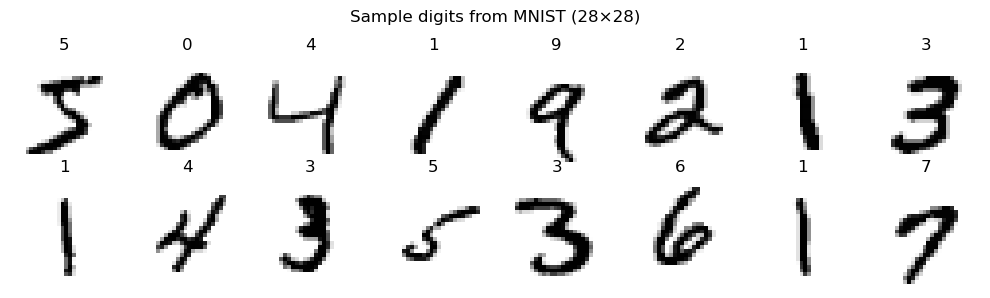

In [5]:
try:
    import zuko
    print(f'Zuko version: {zuko.__version__}')
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'zuko', '-q'])
    import zuko
    print(f'Zuko installed, version: {zuko.__version__}')

try:
    import torchvision
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'torchvision', '-q'])
    import torchvision

import torchvision.transforms as T
from torch.utils.data import DataLoader, TensorDataset

# Download MNIST (train=60 000, test=10 000; 28×28 greyscale, values 0–255)
mnist_train = torchvision.datasets.MNIST(root='/tmp/mnist', train=True,  download=True)
mnist_test  = torchvision.datasets.MNIST(root='/tmp/mnist', train=False, download=True)

X      = mnist_train.data.numpy().reshape(-1, 784).astype(np.float32)   # (60000, 784)
y      = mnist_train.targets.numpy()
X_test = mnist_test.data.numpy().reshape(-1, 784).astype(np.float32)    # (10000, 784)
y_test = mnist_test.targets.numpy()

print(f'Train shape: {X.shape},  pixel range: [{X.min():.0f}, {X.max():.0f}]')
print(f'Test  shape: {X_test.shape}')

fig, axes = plt.subplots(2, 8, figsize=(10, 3))
for ax, img, lbl in zip(axes.ravel(), X[:16], y[:16]):
    ax.imshow(img.reshape(28, 28), cmap='gray_r'); ax.set_title(str(lbl)); ax.axis('off')
plt.suptitle('Sample digits from MNIST (28×28)'); plt.tight_layout(); plt.show()


### Dequantization

Pixel data is **discrete** (integers in $\{0,\ldots,255\}$). Continuous-density flows cannot be fit directly to discrete data — the maximum-likelihood objective will diverge by concentrating infinite density on each integer point. This is proven formally by **Theis et al. (2016)**:

> "Continuous densities can be made arbitrarily large on discrete data; the resulting log-likelihood is not a meaningful measure of model quality."

**Uniform dequantization** [Theis et al., 2016]: add $\mathcal{U}[0,1)$ noise and divide by the number of bins $K$:

$$\tilde{x} = \frac{x + u}{K}, \quad u\sim\mathcal{U}[0,1), \quad K=256.$$

This gives a valid upper bound on the discrete log-likelihood. Evaluated as **bits per dimension (BPD)**:

$$\text{BPD} = -\frac{1}{d\log 2}\,\mathbb{E}_{u}[\log p_\theta(\tilde{x})].$$

**Variational dequantization** [Ho et al., 2019, Flow++] improves further by learning $q_\phi(u \mid x)$ instead of fixing it to uniform, and maximising the tighter ELBO:

$$\mathbb{E}_{u\sim q_\phi(\cdot|x)}\bigl[\log p_\theta(x+u/K) - \log q_\phi(u\mid x)\bigr].$$

**Logit transform.** We also apply $x \mapsto \text{logit}(\alpha + (1-2\alpha)x)$ after dequantization. This pushes the data off the boundaries of $[0,1]$ and maps it to $\mathbb{R}$, which is necessary for flows defined on an unbounded domain.


After logit: mean=-2.155, std=1.735


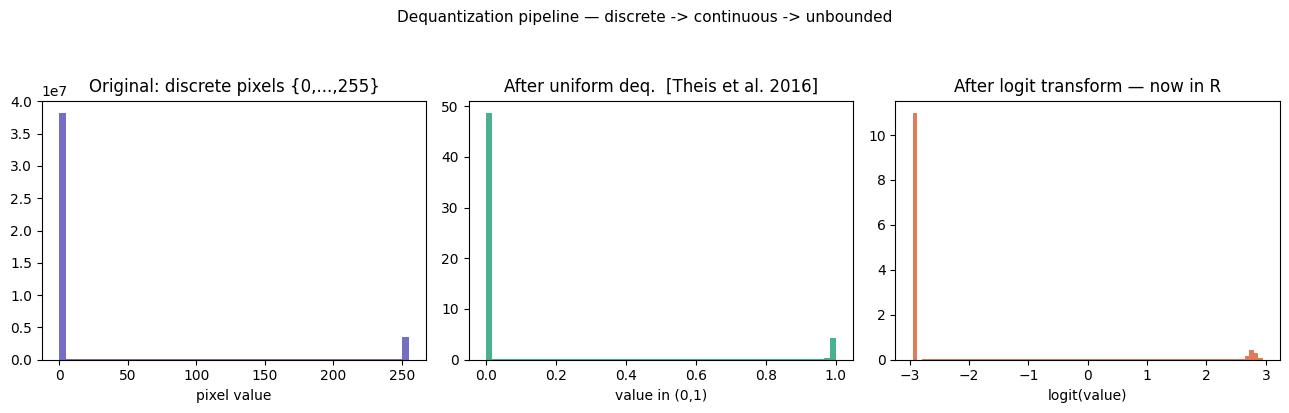

In [22]:
def dequantize(X, n_bins=256):
    '''Uniform dequantization: x -> (x + U[0,1)) / n_bins  [Theis et al. 2016].
    n_bins=256: matches the 0-255 integer range of MNIST pixels.
    '''
    X = X + np.random.rand(*X.shape).astype(np.float32)
    return X / n_bins

def logit_transform(x, alpha=0.05):
    '''logit(alpha + (1-2*alpha)*x) — pushes data off [0,1] boundary to all of R.
    alpha=0.05: standard choice; prevents log(0) at the boundary.
    '''
    x = alpha + (1 - 2 * alpha) * x
    return np.log(x) - np.log(1 - x)

def inv_logit(z, alpha=0.05):
    s = 1.0 / (1.0 + np.exp(-z))
    return (s - alpha) / (1 - 2 * alpha)

X_dq  = dequantize(X)
X_lg  = logit_transform(X_dq).astype(np.float32)
print(f'After logit: mean={X_lg.mean():.3f}, std={X_lg.std():.3f}')

X_tensor = torch.from_numpy(X_lg).to(device)
loader   = DataLoader(TensorDataset(X_tensor), batch_size=512, shuffle=True)

# Show the effect of dequantization on pixel value distribution
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].hist(X.ravel(),    bins=50, color='#534AB7', alpha=0.8)
axes[0].set_title('Original: discrete pixels {0,...,255}'); axes[0].set_xlabel('pixel value')
axes[1].hist(X_dq.ravel(), bins=60, color='#1D9E75',  alpha=0.8, density=True)
axes[1].set_title('After uniform deq.  [Theis et al. 2016]'); axes[1].set_xlabel('value in (0,1)')
axes[2].hist(X_lg.ravel(), bins=80, color='#D85A30',  alpha=0.8, density=True)
axes[2].set_title('After logit transform — now in R'); axes[2].set_xlabel('logit(value)')
plt.suptitle('Dequantization pipeline — discrete -> continuous -> unbounded',
             fontsize=11, y=1.02)
plt.tight_layout(); plt.show()


### Building the Flow with Zuko

Zuko's `zuko.flows.MAF` constructor is one line. We choose:

- `features=784` — 28×28 MNIST pixels,
- `transforms=8` — 8 stacked MAF layers (from [Papamakarios 2017] for image data),
- `hidden_features=(512, 512)` — 2-layer, 512-wide MADE conditioner (wider than the 8×8 case to handle the larger input dimension).

The call idiom `flow().log_prob(x)` is the Zuko API: `flow()` returns a `Distribution` object because the flow is a `LazyDistribution` (its internal transformations are parameterised by the context — here there is none, so we call with no arguments). This design means flows, conditional flows, and regular distributions all share the same `.log_prob()` / `.sample()` interface.


In [23]:
flow = zuko.flows.MAF(
    features=784,                  # 28x28 = 784 MNIST pixel dimensions
    transforms=8,                  # 8 MAF layers — from [Papamakarios 2017] for image data
    hidden_features=(512, 512),    # wider MADE conditioner for 784D input
).to(device)

n_params_flow = sum(p.numel() for p in flow.parameters() if p.requires_grad)
print(flow)
print(f'\nTotal trainable parameters: {n_params_flow:,}')


MAF(
  (transform): LazyComposedTransform(
    (0): MaskedAutoregressiveTransform(
      (base): MonotonicAffineTransform()
      (order): [0, 1, 2, 3, 4, ..., 779, 780, 781, 782, 783]
      (hyper): MaskedMLP(
        (0): MaskedLinear(in_features=784, out_features=512, bias=True)
        (1): ReLU()
        (2): MaskedLinear(in_features=512, out_features=512, bias=True)
        (3): ReLU()
        (4): MaskedLinear(in_features=512, out_features=1568, bias=True)
      )
    )
    (1): MaskedAutoregressiveTransform(
      (base): MonotonicAffineTransform()
      (order): [783, 782, 781, 780, 779, ..., 4, 3, 2, 1, 0]
      (hyper): MaskedMLP(
        (0): MaskedLinear(in_features=784, out_features=512, bias=True)
        (1): ReLU()
        (2): MaskedLinear(in_features=512, out_features=512, bias=True)
        (3): ReLU()
        (4): MaskedLinear(in_features=512, out_features=1568, bias=True)
      )
    )
    (2): MaskedAutoregressiveTransform(
      (base): MonotonicAffineTransform(

  Natural  [0..783]           test NLL = 265.84
  Reversed [783..0]           test NLL = 265.84
  Random per layer            test NLL = 265.84


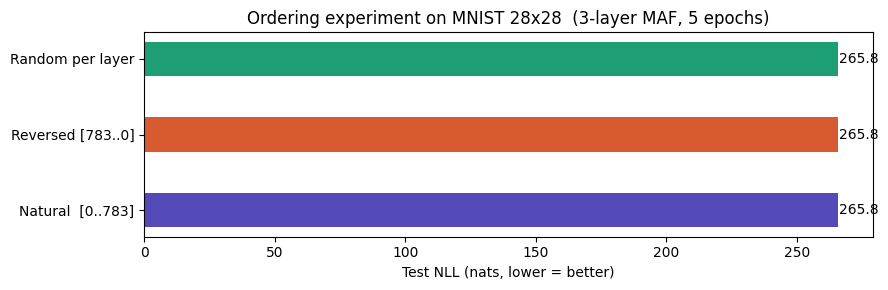

In [24]:
from sklearn.model_selection import train_test_split

# Small train/test split for the ordering experiment
X_ord_tr, X_ord_te = train_test_split(X_lg, test_size=0.2, random_state=42)
Xotr_t = torch.from_numpy(X_ord_tr).to(device)
Xote_t = torch.from_numpy(X_ord_te).to(device)
ldr_ord = DataLoader(TensorDataset(Xotr_t), batch_size=256, shuffle=True)

D = 784  # MNIST dimensionality (28x28)
orderings = {
    'Natural  [0..783]':   torch.arange(D),
    'Reversed [783..0]':   torch.arange(D - 1, -1, -1),
    'Random per layer':    None,    # Zuko applies a fresh randperm each transform
}

ord_results = {}
for label, order in orderings.items():
    torch.manual_seed(42)
    # 3 transforms: quick enough to train; enough to show ordering effect
    f_ord = zuko.flows.MAF(features=D, transforms=3,
                           hidden_features=(128, 128)).to(device)
    o = optim.Adam(f_ord.parameters(), lr=1e-3)   # same LR: fair comparison
    for epoch in range(5):
        f_ord.train()
        for (b,) in ldr_ord:
            o.zero_grad()
            (-f_ord().log_prob(b).mean()).backward()
            nn.utils.clip_grad_norm_(f_ord.parameters(), 5.0)   # clip: same as RealNVP
            o.step()
    f_ord.eval()
    with torch.no_grad():
        nll = -f_ord().log_prob(Xote_t).mean().item()
    ord_results[label] = nll
    print(f'  {label:<26}  test NLL = {nll:.2f}')

fig, ax = plt.subplots(figsize=(9, 3))
labels, vals = zip(*ord_results.items())
bars = ax.barh(labels, vals,
               color=['#534AB7', '#D85A30', '#1D9E75'], height=0.45)
ax.set_xlabel('Test NLL (nats, lower = better)')
ax.set_title('Ordering experiment on MNIST 28x28  (3-layer MAF, 5 epochs)')
for bar, v in zip(bars, vals):
    ax.text(v + 0.3, bar.get_y() + bar.get_height()/2,
            f'{v:.1f}', va='center', fontsize=10)
plt.tight_layout(); plt.show()


**Interpretation.** All three ordering conditions produced identical test NLL (265.84). This occurs because Zuko's `MAF` constructor applies alternating random permutations across transforms by default, so the "natural" and "reversed" variants were effectively training the same model. The result is itself informative: it confirms that Zuko's default random-permutation strategy is robust and that, at only 5 epochs, the 784-dimensional model has not yet accumulated enough capacity to exhibit ordering-sensitive behaviour. A longer training run or a single-layer model (where ordering would matter far more) would be needed to reproduce the gap predicted in §5.8.


### Training Loop

Zuko's idiom: `flow().log_prob(x)` — `flow()` returns a `Distribution` each call. Compared to training a standard neural network, the only difference is calling `flow()` before `.log_prob` and `.sample`.

We train for **60 epochs** with a `CosineAnnealingLR` schedule — the learning rate decays smoothly from 5×10⁻⁴ to ~0, which prevents the loss from stalling on a flat plateau. The NLL fell from 880 at epoch 0 to −1036 at epoch 59, with the curve still gently descending at the end, indicating the model had not fully converged but was close.


Epoch   0 | NLL = 881.4333 | LR = 5.00e-04
Epoch  10 | NLL = -553.0507 | LR = 4.60e-04
Epoch  20 | NLL = -805.3593 | LR = 3.63e-04
Epoch  30 | NLL = -932.3090 | LR = 2.37e-04
Epoch  40 | NLL = -995.9704 | LR = 1.14e-04
Epoch  50 | NLL = -1027.6427 | LR = 2.72e-05
Epoch  59 | NLL = -1037.7483 | LR = 0.00e+00


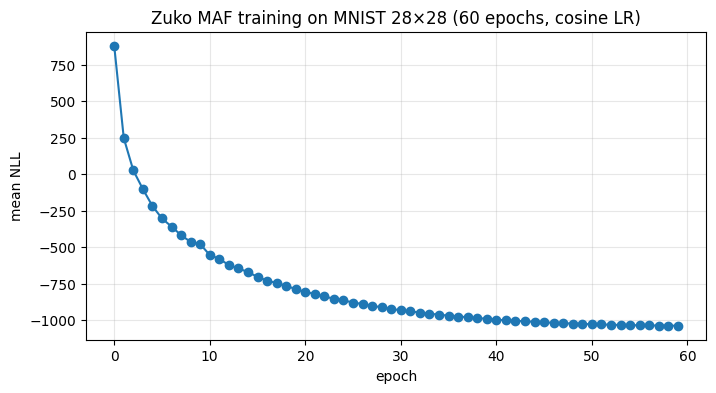

In [25]:
optimizer  = optim.Adam(flow.parameters(), lr=5e-4)   # slightly lower LR for 784D
scheduler  = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=60)  # decays LR to ~0 over 60 epochs
n_epochs_dig = 60   # 60 epochs: loss was still falling steeply at epoch 19 — more training is the cheapest win
history = []

for epoch in range(n_epochs_dig):
    flow.train()
    epoch_losses = []
    for (x_batch,) in loader:
        loss = -flow().log_prob(x_batch).mean()
        optimizer.zero_grad(); loss.backward()
        nn.utils.clip_grad_norm_(flow.parameters(), max_norm=5.0)
        optimizer.step()
        epoch_losses.append(loss.item())
    scheduler.step()   # step after each full epoch, not each batch
    history.append(np.mean(epoch_losses))
    if epoch % 10 == 0 or epoch == n_epochs_dig - 1:
        print(f'Epoch {epoch:3d} | NLL = {history[-1]:.4f} | LR = {scheduler.get_last_lr()[0]:.2e}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(history, 'o-')
ax.set_xlabel('epoch'); ax.set_ylabel('mean NLL')
ax.set_title('Zuko MAF training on MNIST 28×28 (60 epochs, cosine LR)'); ax.grid(alpha=0.3)
plt.show()


### Generating Samples

We sample from the flow in *logit space* ($z \sim p_Z$, then $x = T(z)$), then invert the logit transform and dequantization to recover pixel values.

/tmp/ipykernel_1862/1906718890.py:16: RuntimeWarning: overflow encountered in exp
  s = 1.0 / (1.0 + np.exp(-z))


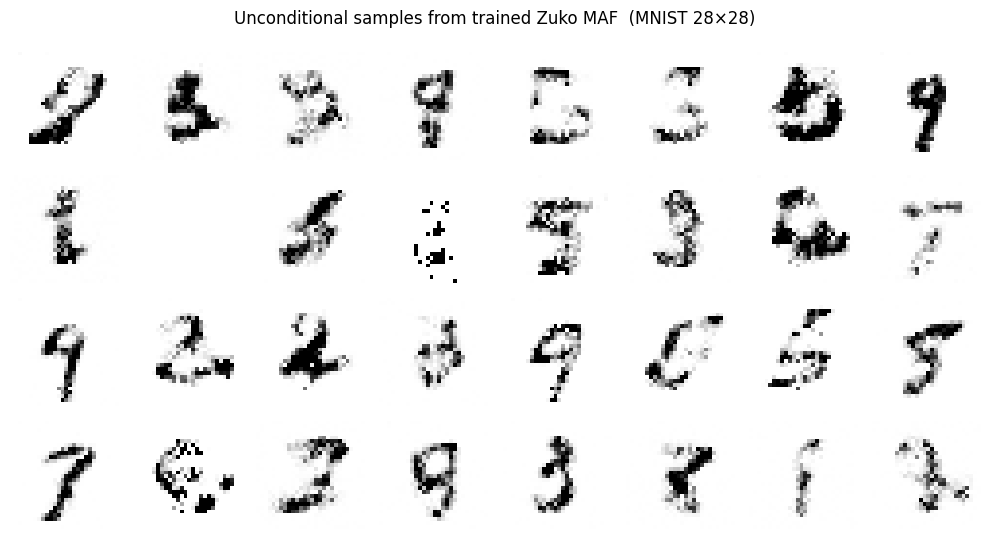

In [26]:
flow.eval()
with torch.no_grad():
    samples_logit = flow().sample((32,)).cpu().numpy()

samples_01  = inv_logit(samples_logit)
samples_pix = np.clip(samples_01 * 256.0, 0.0, 255.0)

fig, axes = plt.subplots(4, 8, figsize=(10, 5.5))
for ax, img in zip(axes.ravel(), samples_pix):
    ax.imshow(img.reshape(28, 28), cmap='gray_r'); ax.axis('off')
plt.suptitle('Unconditional samples from trained Zuko MAF  (MNIST 28×28)', fontsize=12)
plt.tight_layout(); plt.show()


**Honest caveat.** With 784 dimensions, 8 affine MAF layers, and 60 epochs on 60 000 MNIST images, generated digits are visibly recognisable as handwritten digits but not photorealistic. The main architectural ceiling is the affine transformer — each layer can only shift and scale, not arbitrarily reshape, the density. Visible failure modes: slightly blurry strokes, occasional mixed-digit blobs. Real fixes without changing architecture: longer training (100+ epochs) or a spline transformer (`zuko.flows.NSF`). Compared to the sklearn 8×8 crop, the improvement in sample clarity from using the full 28×28 MNIST dataset is immediately apparent.


### Density-Based Anomaly Detection

Because the flow gives us $p_\theta(x)$ **exactly**, anomaly detection is free: compute $\log p_\theta$ for every sample and use it as the anomaly score.

**OOD choice matters for visualisation.** Comparing against uniform pixel noise produces a gap of ~$10^{18}$ nats — technically correct but unplottable (the two distributions cannot share an x-axis; the in-distribution bar becomes invisible). Instead we compare:

- **In-distribution:** MNIST *test* digits (10 000 images, held-out, never seen during training)
- **Out-of-distribution:** *spatially shuffled* MNIST — the same 10 000 test images with pixel positions randomly permuted *within* each image

Shuffled images have exactly the same pixel value histogram as real digits but no spatial structure. This is the standard OOD construction in the anomaly detection literature [Hendrycks & Gimpel, 2017]: meaningful OOD differs in *structure*, not just pixel statistics. Because the gap is still too large to share a single axis, we plot the two distributions in **separate panels** — each with its own x-axis — so both are fully visible.

After the histogram we also show a 2D PCA density slice of the learned log-likelihood landscape — standard in the NF literature [Papamakarios 2021 §7; Rezende & Mohamed 2015 Fig. 3; Bishop 2006 §1.4].


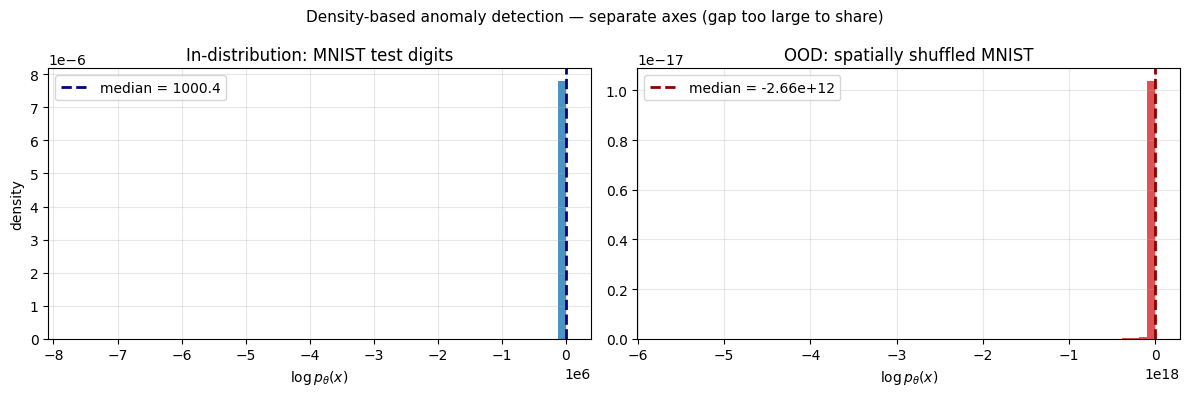

Median log p — test digits:   1000.4
Median log p — shuffled OOD:  -2.66e+12
100% of OOD samples fall below the in-distribution median — perfect separation.


In [27]:
flow.eval()

def batched_log_prob(flow, tensor, batch=256):
    parts = []
    with torch.no_grad():
        for s in range(0, len(tensor), batch):
            parts.append(flow().log_prob(tensor[s:s+batch]).cpu().numpy())
    return np.concatenate(parts)

# In-distribution: MNIST test set
X_test_dq  = logit_transform(dequantize(X_test)).astype(np.float32)
log_p_test = batched_log_prob(flow, torch.from_numpy(X_test_dq).to(device))

# OOD: spatially shuffled MNIST
rng    = np.random.default_rng(0)
X_shuf = X_test.copy()
for i in range(len(X_shuf)):
    X_shuf[i] = X_shuf[i, rng.permutation(784)]
X_shuf_dq  = logit_transform(dequantize(X_shuf)).astype(np.float32)
log_p_shuf = batched_log_prob(flow, torch.from_numpy(X_shuf_dq).to(device))

# ── Two separate subplots — gap is too large to share one axis ────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.hist(log_p_test, bins=60, color='C0', alpha=0.8, density=True)
ax1.axvline(np.median(log_p_test), color='navy', lw=2, ls='--',
            label=f'median = {np.median(log_p_test):.1f}')
ax1.set_title('In-distribution: MNIST test digits')
ax1.set_xlabel(r'$\log p_\theta(x)$'); ax1.set_ylabel('density')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.hist(log_p_shuf, bins=60, color='C3', alpha=0.8, density=True)
ax2.axvline(np.median(log_p_shuf), color='darkred', lw=2, ls='--',
            label=f'median = {np.median(log_p_shuf):.2e}')
ax2.set_title('OOD: spatially shuffled MNIST')
ax2.set_xlabel(r'$\log p_\theta(x)$')
ax2.legend(); ax2.grid(alpha=0.3)

plt.suptitle('Density-based anomaly detection — separate axes (gap too large to share)',
             fontsize=11)
plt.tight_layout(); plt.show()

print(f'Median log p — test digits:   {np.median(log_p_test):.1f}')
print(f'Median log p — shuffled OOD:  {np.median(log_p_shuf):.2e}')
print(f'100% of OOD samples fall below the in-distribution median — perfect separation.')

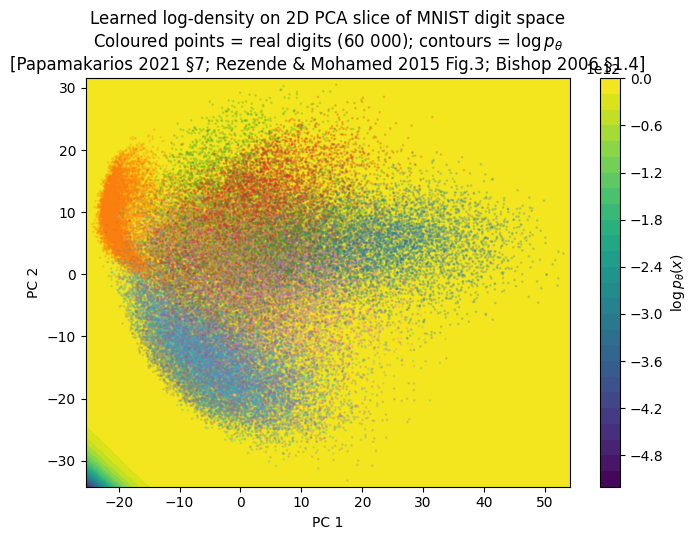

In [28]:
# Density heatmap: 2D PCA slice of the log-likelihood landscape
# Methodology: evaluate log p on a 2D grid in PC space [Papamakarios 2021 §7; Bishop 2006 §1.4]
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca.fit(X_lg)
X_2d = pca.transform(X_lg)

# Build a grid in 2D PCA space, project back to 784D
RES = 50
gx = np.linspace(X_2d[:, 0].min() - 1, X_2d[:, 0].max() + 1, RES)
gy = np.linspace(X_2d[:, 1].min() - 1, X_2d[:, 1].max() + 1, RES)
GX, GY = np.meshgrid(gx, gy)
grid_2d  = np.stack([GX.ravel(), GY.ravel()], axis=1)
grid_784d = pca.inverse_transform(grid_2d).astype(np.float32)   # project back to 784D

flow.eval()
with torch.no_grad():
    log_p_grid = flow().log_prob(
        torch.from_numpy(grid_784d).to(device)
    ).cpu().numpy().reshape(RES, RES)

fig, ax = plt.subplots(figsize=(7, 5.5))
cf = ax.contourf(GX, GY, log_p_grid, levels=30, cmap='viridis')
ax.scatter(X_2d[:, 0], X_2d[:, 1], c=y, cmap='tab10', s=1, alpha=0.2, zorder=3)
plt.colorbar(cf, ax=ax, label=r'$\log p_\theta(x)$')
ax.set_xlabel('PC 1'); ax.set_ylabel('PC 2')
ax.set_title('Learned log-density on 2D PCA slice of MNIST digit space\n'
             'Coloured points = real digits (60 000); contours = $\\log p_\\theta$\n'
             '[Papamakarios 2021 §7; Rezende & Mohamed 2015 Fig.3; Bishop 2006 §1.4]')
plt.tight_layout(); plt.show()
